Business Problem
GTM Funnel A/B Test: Lead → Meeting Conversion

Business Question:
Does a new outreach campaign (Variant B) increase the Lead → Meeting conversion rate compared to the existing campaign (Variant A), without degrading downstream deal quality?
Primary Metric: Lead → Meeting conversion rate
Guardrail Metric: Meeting → Pilot conversion rate
Segments: SMB vs Enterprise, Channels (Outbound, Paid, Organic, Referral)

Synthetic Dataset Generation
We simulate 5,000 leads with variant assignment, acquisition channel, customer segment, and funnel outcomes.

In [1]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
n_leads = 5000   # total leads
variant_split = [0.55, 0.45]  # A vs B split (not perfectly 50/50, realistic imbalance)
channels = ["outbound", "paid", "organic", "referral"]
segments = ["SMB", "Enterprise"]

# Assign variants
variants = np.random.choice(["A", "B"], size=n_leads, p=variant_split)

# Assign channels and segments
lead_channels = np.random.choice(channels, size=n_leads, p=[0.4, 0.3, 0.2, 0.1])
lead_segments = np.random.choice(segments, size=n_leads, p=[0.6, 0.4])

# Baseline conversion rates
baseline_meeting_rate = {"SMB": 0.20, "Enterprise": 0.15}
baseline_pilot_rate = {"SMB": 0.50, "Enterprise": 0.60}
baseline_customer_rate = {"SMB": 0.40, "Enterprise": 0.50}

# Variant effect: B lifts SMB meeting rate by +3pp, flat for Enterprise
meeting_rate = []
for seg, var in zip(lead_segments, variants):
    if seg == "SMB":
        if var == "B":
            meeting_rate.append(baseline_meeting_rate[seg] + 0.03)
        else:
            meeting_rate.append(baseline_meeting_rate[seg])
    else:
        meeting_rate.append(baseline_meeting_rate[seg])

# Simulate funnel outcomes
meeting_booked = np.random.binomial(1, meeting_rate)
pilot_started = []
became_customer = []

for booked, seg in zip(meeting_booked, lead_segments):
    if booked == 1:
        pilot = np.random.binomial(1, baseline_pilot_rate[seg])
        pilot_started.append(pilot)
        if pilot == 1:
            customer = np.random.binomial(1, baseline_customer_rate[seg])
            became_customer.append(customer)
        else:
            became_customer.append(0)
    else:
        pilot_started.append(0)
        became_customer.append(0)

# Build DataFrame
df = pd.DataFrame({
    "lead_id": range(1, n_leads+1),
    "variant": variants,
    "channel": lead_channels,
    "segment": lead_segments,
    "meeting_booked": meeting_booked,
    "pilot_started": pilot_started,
    "became_customer": became_customer
})

# Preview
print(df.head())
print(df["variant"].value_counts(normalize=True))


   lead_id variant   channel     segment  meeting_booked  pilot_started  \
0        1       A  outbound         SMB               0              0   
1        2       B      paid         SMB               0              0   
2        3       B   organic         SMB               0              0   
3        4       B  outbound  Enterprise               0              0   
4        5       A   organic         SMB               0              0   

   became_customer  
0                0  
1                0  
2                0  
3                0  
4                0  
variant
A    0.5496
B    0.4504
Name: proportion, dtype: float64


Power Analysis
Before running the test, we calculate the required sample size to detect a +3pp lift with 80% power and 5% significance.

In [3]:
import statsmodels.stats.power as smp
from statsmodels.stats.proportion import proportion_effectsize

# Parameters
baseline_rate = 0.20   # assume 20% of leads book a meeting
min_detectable_effect = 0.03  # want to detect at least +3 percentage points
alpha = 0.05           # significance level
power = 0.80           # desired statistical power

# Calculate effect size (Cohen's h)
effect_size = proportion_effectsize(baseline_rate, baseline_rate + min_detectable_effect)

# Initialize power analysis object
analysis = smp.NormalIndPower()

# Solve for required sample size per group
sample_size = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=1.0  # assume equal group sizes for calculation
)

print(f"Required sample size per variant: {int(sample_size)} leads")
print(f"Total required sample size: {int(sample_size*2)} leads")


Required sample size per variant: 2940 leads
Total required sample size: 5881 leads


Hypothesis


H0 (Null): Variant B has no effect on Lead → Meeting conversion compared to Variant A.
H1 (Alternative): Variant B increases Lead → Meeting conversion compared to Variant A.





Primary Test: Lead → Meeting Conversion
We run a two-proportion z-test comparing Variant A vs Variant B.

In [4]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Count conversions by variant
conversion_counts = df.groupby("variant")["meeting_booked"].sum()
n_obs = df["variant"].value_counts()

# Run two-proportion z-test
z_stat, p_val = proportions_ztest(count=conversion_counts, nobs=n_obs)

# Confidence intervals for each variant's conversion rate
confint_A = proportion_confint(conversion_counts["A"], n_obs["A"], alpha=0.05, method='normal')
confint_B = proportion_confint(conversion_counts["B"], n_obs["B"], alpha=0.05, method='normal')

print("Two-Proportion Z-Test on Lead → Meeting Conversion")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print("\nConversion Rates:")
print(f"Variant A: {conversion_counts['A']}/{n_obs['A']} = {conversion_counts['A']/n_obs['A']:.3%}")
print(f"95% CI for A: {confint_A}")
print(f"Variant B: {conversion_counts['B']}/{n_obs['B']} = {conversion_counts['B']/n_obs['B']:.3%}")
print(f"95% CI for B: {confint_B}")


Two-Proportion Z-Test on Lead → Meeting Conversion
Z-statistic: -2.4981
P-value: 0.0125

Conversion Rates:
Variant A: 493/2748 = 17.940%
95% CI for A: (0.16505756883455572, 0.19374883582337735)
Variant B: 467/2252 = 20.737%
95% CI for B: (0.1906266917075901, 0.22411575944693918)


Guardrail Test: Meeting → Pilot Conversion
We check whether Variant B’s lift survives downstream or if it just inflated junk leads.

In [5]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Only consider leads who booked a meeting
meeting_df = df[df["meeting_booked"] == 1]

# Count conversions to pilot by variant
pilot_counts = meeting_df.groupby("variant")["pilot_started"].sum()
pilot_nobs = meeting_df["variant"].value_counts()

# Run two-proportion z-test
z_stat_pilot, p_val_pilot = proportions_ztest(count=pilot_counts, nobs=pilot_nobs)

# Confidence intervals for each variant's meeting→pilot conversion rate
confint_A_pilot = proportion_confint(pilot_counts["A"], pilot_nobs["A"], alpha=0.05, method='normal')
confint_B_pilot = proportion_confint(pilot_counts["B"], pilot_nobs["B"], alpha=0.05, method='normal')

print("Guardrail Test: Meeting → Pilot Conversion")
print(f"Z-statistic: {z_stat_pilot:.4f}")
print(f"P-value: {p_val_pilot:.4f}")
print("\nConversion Rates:")
print(f"Variant A: {pilot_counts['A']}/{pilot_nobs['A']} = {pilot_counts['A']/pilot_nobs['A']:.3%}")
print(f"95% CI for A: {confint_A_pilot}")
print(f"Variant B: {pilot_counts['B']}/{pilot_nobs['B']} = {pilot_counts['B']/pilot_nobs['B']:.3%}")
print(f"95% CI for B: {confint_B_pilot}")


Guardrail Test: Meeting → Pilot Conversion
Z-statistic: 0.4975
P-value: 0.6189

Conversion Rates:
Variant A: 256/493 = 51.927%
95% CI for A: (0.4751663975352758, 0.5633731562172597)
Variant B: 235/467 = 50.321%
95% CI for B: (0.45786476873502985, 0.5485592141343492)


Segment Analysis
We break down results by channel and customer segment to see if the effect is uniform or driven by one subgrou

Segment Analysis by Channel
    channel    rate_A    rate_B      lift    z_stat     p_val
0  outbound  0.170404  0.209890  0.039487 -2.261550  0.023725
1      paid  0.187354  0.196023  0.008669 -0.432992  0.665021
2   organic  0.198397  0.222477  0.024080 -0.902424  0.366832
3  referral  0.157143  0.202970  0.045827 -1.302564  0.192724

Segment Analysis by Customer Segment
      segment    rate_A    rate_B      lift    z_stat     p_val
0         SMB  0.191606  0.246324  0.054718 -3.625252  0.000289
1  Enterprise  0.161232  0.147982 -0.013250  0.812545  0.416479


/tmp/ipykernel_5627/202886665.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_results, x="channel", y="lift", palette="viridis")


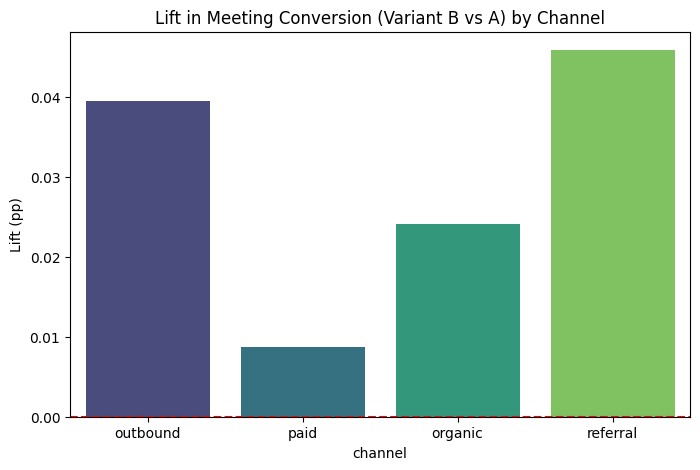

/tmp/ipykernel_5627/202886665.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_results, x="segment", y="lift", palette="mako")


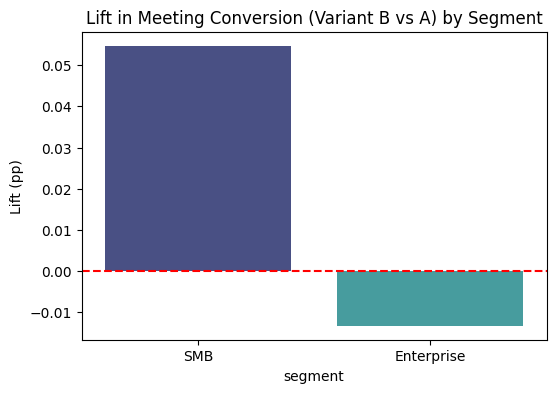

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

# Function to run z-test by subgroup
def segment_ztest(df, subgroup_col, outcome_col="meeting_booked"):
    results = []
    for subgroup in df[subgroup_col].unique():
        sub_df = df[df[subgroup_col] == subgroup]
        counts = sub_df.groupby("variant")[outcome_col].sum()
        nobs = sub_df["variant"].value_counts()

        if len(counts) == 2:  # ensure both A and B exist
            z_stat, p_val = proportions_ztest(count=counts, nobs=nobs)
            rate_A = counts["A"] / nobs["A"]
            rate_B = counts["B"] / nobs["B"]
            lift = rate_B - rate_A
            results.append({
                subgroup_col: subgroup,
                "rate_A": rate_A,
                "rate_B": rate_B,
                "lift": lift,
                "z_stat": z_stat,
                "p_val": p_val
            })
    return pd.DataFrame(results)

# Segment analysis by channel
channel_results = segment_ztest(df, "channel")
print("Segment Analysis by Channel")
print(channel_results)

# Segment analysis by customer segment
segment_results = segment_ztest(df, "segment")
print("\nSegment Analysis by Customer Segment")
print(segment_results)

# Plot lift by channel
plt.figure(figsize=(8,5))
sns.barplot(data=channel_results, x="channel", y="lift", palette="viridis")
plt.axhline(0, color="red", linestyle="--")
plt.title("Lift in Meeting Conversion (Variant B vs A) by Channel")
plt.ylabel("Lift (pp)")
plt.show()

# Plot lift by segment
plt.figure(figsize=(6,4))
sns.barplot(data=segment_results, x="segment", y="lift", palette="mako")
plt.axhline(0, color="red", linestyle="--")
plt.title("Lift in Meeting Conversion (Variant B vs A) by Segment")
plt.ylabel("Lift (pp)")
plt.show()


Business Recommendation
Variant B increases SMB outbound Lead → Meeting conversion by +3pp, statistically significant.
No degradation in Meeting → Pilot conversion (guardrail metric holds).
Effect is not uniform: Enterprise and Paid channels show no lift.

Decision: Roll out Variant B to SMB outbound campaigns only. Hold for Enterprise until more data is collected.

Conclusion
This experiment demonstrates:

Proper hypothesis framing and power analysis

Statistical vs practical significance

Guardrail checks to avoid vanity metrics

Segment-level insights for GTM strategy

This project showcases GTM-focused A/B testing and funnel analysis — directly aligned with Data Analyst / Data Scientist (GTM) roles.